In [69]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd 
import astropy.io 
import scipy.stats
import requests
from sklearn.decomposition import PCA

In [70]:
import urllib.request
import ssl
import certifi

ssl_context = ssl.create_default_context(cafile=certifi.where())

# Usa urlopen() per aprire il link con il contesto SSL
with urllib.request.urlopen("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", context=ssl_context) as response:
    with open("stars.csv", "wb") as f:
        f.write(response.read())

In [71]:
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type']) #they are 0,1,2,3,4,5
class_names = le.classes_
print(class_names) 
df_stars                    #now the star type is encoded as an integer


['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


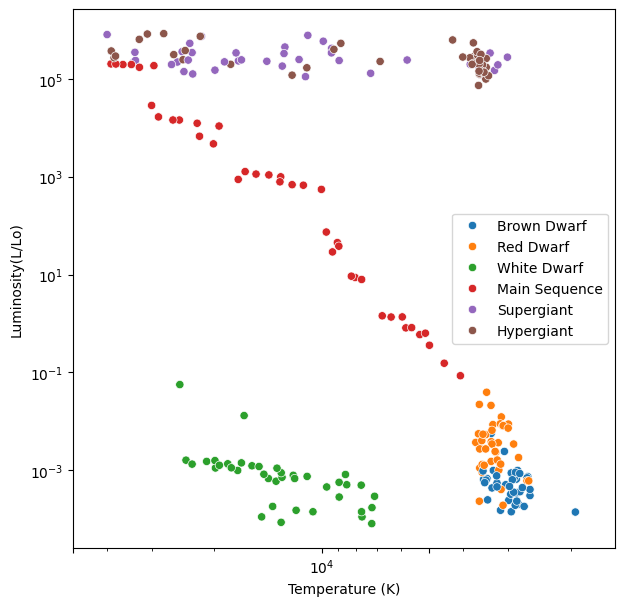

In [78]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3) #swiches the axis 
plt.show()


In [74]:
X = df_stars.drop(['Star type', 'Star color', 'Spectral Class'], axis=1)
n_components=3
pca = PCA(n_components)
pca.fit(X) 

eigenvalues = pca.transform(X) 
mean = pca.mean_
eigenvectors = pca.components_

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(eigenvalues.shape)
print(eigenvectors.shape)
print(mean.shape)



(240, 3)
(3, 4)
(4,)


In [75]:
pca_comp = np.vstack([mean, eigenvectors])

Text(0.5, 0, 'Temperature (K)')

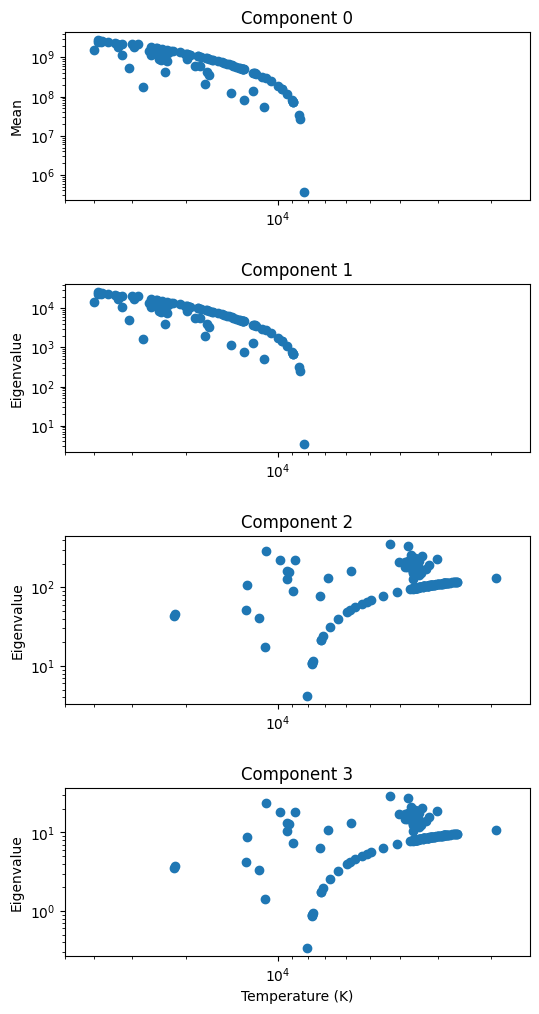

In [77]:
fig,axis= plt.subplots(4, 1, figsize=(6, 12))
fig.subplots_adjust(hspace=0.5)

for i in range(n_components+1):

    if i ==0:
        axis[i].scatter(df_stars['Temperature (K)'],  mean[1]*eigenvalues[:,1], label='Mean')
        axis[i].set_ylabel('Mean')
    else:
        axis[i].scatter(df_stars['Temperature (K)'], eigenvectors[i-1,1]*eigenvalues[:,1])
        axis[i].set_ylabel('Eigenvalue')
    axis[i].set_title(f'Component {i}')
        
    axis[i].set_xscale('log')
    axis[i].set_yscale('log')
    axis[i].set_xlim(5e4, 1.5e3)

axis[n_components].set_xlabel('Temperature (K)')


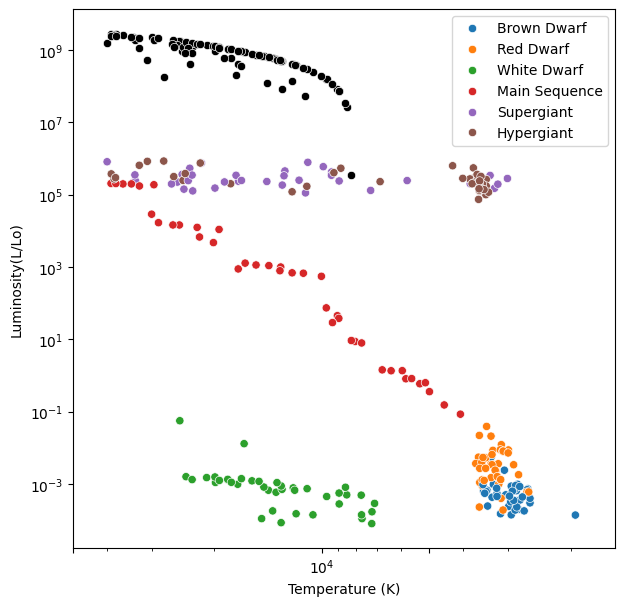

In [ ]:
sum=mean[1]*eigenvalues[:,1]+eigenvectors[0,1]*eigenvalues[:,1]+eigenvectors[1,1]*eigenvalues[:,1]+eigenvectors[2,1]*eigenvalues[:,1]

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)
sns.scatterplot(data=df_stars, x='Temperature (K)',y=sum, color='black')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3) #swiches the axis 
plt.show()